## 02. Scratchpad

### 1. File handling via Data.py 

In [1]:
import Data
import matplotlib.pyplot as plt

In [2]:
path = '../data/tatoeba_1/eng-pol_1.tsv'
df = Data.upload_tsv(path=path, col_drop=[0, 2])
df.head(3)

,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.


In [3]:
df_tok = Data.tokenize_data(df=df, src_col='eng_text', tgt_col='pol_text')
df_tok.head(3)

,eng_text,pol_text,eng_len,pol_len
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8


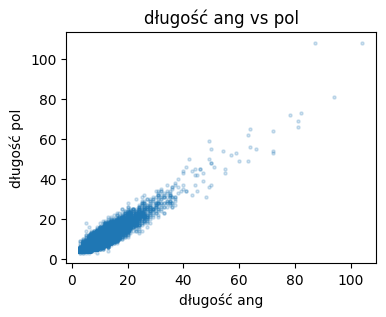

In [4]:
plt.figure(figsize=(4, 3))
plt.scatter(df_tok['eng_len'], df_tok['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

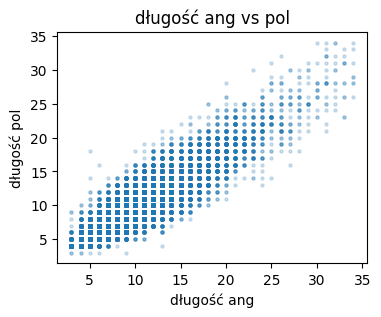

In [5]:
df_trim = Data.trim_data(df=df_tok, src_len='eng_len', tgt_len='pol_len', thres=34)
plt.figure(figsize=(4, 3))
plt.scatter(df_trim['eng_len'], df_trim['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

In [6]:
df_ids, eng_vocab, pol_vocab = Data.tokens_to_id(df=df_trim, src_col='eng_text', tgt_col='pol_text')
df_ids.head(3)

,eng_text,pol_text,eng_len,pol_len,src_ids,tgt_ids
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5,"[157, 271, 122, 3, 2]","[3, 3407, 68, 4, 2]"
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6,"[5, 20, 6, 54, 6, 329, 3, 2]","[3, 89, 103, 293, 4, 2]"
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8,"[3447, 11, 1744, 94, 3, 2]","[3, 4377, 26, 75, 1344, 115, 4, 2]"


In [7]:
df_data = df_ids[['src_ids', 'tgt_ids']]
df_data.head(3)

,src_ids,tgt_ids
0,"[157, 271, 122, 3, 2]","[3, 3407, 68, 4, 2]"
1,"[5, 20, 6, 54, 6, 329, 3, 2]","[3, 89, 103, 293, 4, 2]"
2,"[3447, 11, 1744, 94, 3, 2]","[3, 4377, 26, 75, 1344, 115, 4, 2]"


In [8]:
df_train, df_val = Data.shuffle_split(df=df_data, tr_per=0.8)
print(df_train.shape, df_val.shape)
df_train.head(3)

(67045, 2) (16762, 2)


,src_ids,tgt_ids
0,"[5, 217, 178, 1573, 3, 2]","[3, 538, 10, 54, 23, 4330, 4, 2]"
1,"[327, 58, 4, 1795, 49, 13, 4, 2226, 3, 2]","[3, 201, 97, 1424, 292, 12, 735, 4, 2]"
2,"[5, 20, 22, 318, 2740, 1, 1811, 28, 1983, 3, 2]","[3, 33, 1925, 4561, 13, 605, 3693, 19, 5085, 4..."


In [9]:
train_data = Data.EngPolDataset(df_train, 'src_ids', 'tgt_ids')
val_data = Data.EngPolDataset(df_val, 'src_ids', 'tgt_ids')

In [18]:
test_batch = next(iter(Data.data_loader(train_data, 2)))
test_batch

(tensor([[   5,  217,  178, 1573,    3,    2,    0,    0,    0,    0],
         [ 327,   58,    4, 1795,   49,   13,    4, 2226,    3,    2]]),
 tensor([[   3,  538,   10,   54,   23, 4330,    4,    2,    0],
         [   3,  201,   97, 1424,  292,   12,  735,    4,    2]]),
 tensor([[ 6],
         [10]]))

In [30]:
test_batch[1].size(), test_batch[1]

(torch.Size([2, 9]),
 tensor([[   3,  538,   10,   54,   23, 4330,    4,    2,    0],
         [   3,  201,   97, 1424,  292,   12,  735,    4,    2]]))

In [31]:
test_batch[1][:, :-1]

tensor([[   3,  538,   10,   54,   23, 4330,    4,    2],
        [   3,  201,   97, 1424,  292,   12,  735,    4]])

In [49]:
test_batch[0].shape

torch.Size([2, 10])

In [32]:
import torch

In [272]:
torch.repeat_interleave(test_batch[2], repeats=4, dim=0)

tensor([[ 6],
        [ 6],
        [ 6],
        [ 6],
        [10],
        [10],
        [10],
        [10]])

In [201]:
dec_val = torch.arange(1, 10 + 1).repeat(2, 1)
dec_val.shape, dec_val

(torch.Size([2, 10]),
 tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]]))

In [206]:
dec_valid_len = torch.repeat_interleave(dec_val, repeats=4, dim=0)
dec_valid_len.shape, dec_valid_len

(torch.Size([8, 10]),
 tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]]))

In [283]:
def masked_softmax2(X, valid_lens):
    def _sequence_mask(X, valid_len, value=-1e6):
        if valid_len.size(1) == 1:
            valid_len = valid_len.reshape(-1, 1, 1)
        else:
            valid_len = valid_len.reshape(-1, valid_len.shape[-1], 1)
            
        maxlen = X.size(-1)
        mask = torch.arange((maxlen), dtype=torch.float32, 
                            device=X.device)[None, None, :] < valid_len
        X.masked_fill_(~mask, 0)
        return X

    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        X = _sequence_mask(X, valid_lens, value=-1e6)
        return X
        # return nn.functional.softmax(X, dim=-1)

In [277]:
X_test = torch.ones(8, 10, 10)
test_arange = torch.arange((10), dtype=torch.float32)
dec_valid_len = torch.repeat_interleave(dec_val, repeats=4, dim=0)
X_test.shape, test_arange.shape, dec_valid_len.shape, dec_valid_len

(torch.Size([8, 10, 10]),
 torch.Size([10]),
 torch.Size([8, 10]),
 tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]]))

In [282]:
sigma.size(1)

1

In [280]:
sigma = torch.repeat_interleave(test_batch[2], repeats=4, dim=0)
masked_softmax2(X_test, sigma)

tensor([[[1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.]],

        [[1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1.,

### 2. Training Transformers Model

In [10]:
import Model
import Trainer
import Predict

In [11]:
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(len(eng_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = Model.TransformerDecoder(len(pol_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')

In [12]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test 1")

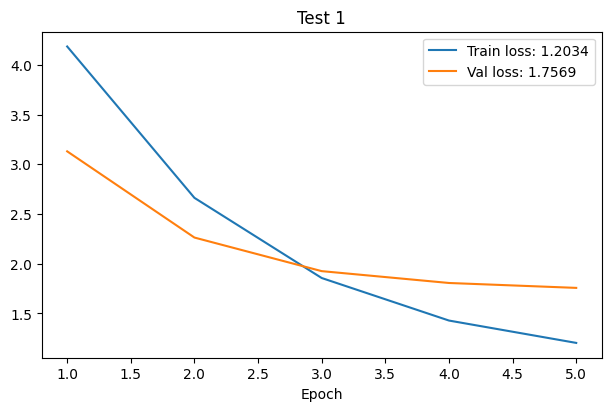

In [13]:
trainer.fit(model, train_data, val_data, 5, '../checkpoints/checkpoint.pt')

### 3. Predicting On Transformers Model

In [20]:
import torch
def snt_to_tokens(snt_eng, vocab_eng, device, max_len=34):
    eng_unk = vocab_eng['<unk>']
    snt_split = Data.tokenize_snt(snt_eng, r"""['"€;:()$%–—‘’°“”₳+&#=‐…−/£@-]""", lambda x: x + ['<eos>'])[:max_len]
    snt_ids = [vocab_eng.get(tok, eng_unk) for tok in snt_split]
    return torch.tensor(snt_ids).reshape(1, -1).to(device), torch.tensor([len(snt_ids)]).reshape(-1, 1).to(device)

def tokens_to_snt(pred_ids, vcb_pol_rev):
    snt_pred = list(map(torch.Tensor.item, pred_ids))
    return [vcb_pol_rev[x] for x in snt_pred]

def predict_step(snt_eng, vcb_eng, vcb_pol, vcb_pol_rev, model, max_len=34):
    device = model.device
    src_eng, src_len = snt_to_tokens(snt_eng, vcb_eng, device, max_len)
    bos_id, eos_id = vcb_pol['<bos>'], vcb_pol['<eos>']
    
    with torch.no_grad():
        model.eval()
        X_enc = model.encoder(src_eng, src_len)
        dec_state = model.decoder.init_state(X_enc, src_len)
        pred_ids = [torch.tensor(bos_id).reshape(1, -1).to(device)]
        print(pred_ids)
        for _ in range(max_len):
            Y_dec, dec_state = model.decoder(pred_ids[-1], dec_state)
            print(Y_dec)
            pred_ids.append(Y_dec.argmax(2))
            if pred_ids[-1].item() == eos_id:
                break
    return tokens_to_snt(pred_ids, vcb_pol_rev)

In [24]:
pol_vocab_rev = {v: k for k, v in pol_vocab.items()}
eng_vocab_rev = {v: k for k, v in eng_vocab.items()}

In [30]:
src_eng, src_len = snt_to_tokens("How are you?", eng_vocab, 'cuda')
src_eng, src_len

(tensor([[50, 24,  7, 10,  2]], device='cuda:0'),
 tensor([[5]], device='cuda:0'))

In [44]:
bos_id, eos_id = pol_vocab['<bos>'], pol_vocab['<eos>']
with torch.no_grad():
    model.eval()
    X_enc = model.encoder(src_eng, src_len)
    dec_state = model.decoder.init_state(X_enc, src_len)
    pred_ids = [torch.tensor(bos_id).reshape(1, -1).to('cuda')]
    Y_dec, dec_state = model.decoder(pred_ids[-1], dec_state)

In [48]:
Y_dec.argmax(2)

tensor([[7]], device='cuda:0')

In [38]:
X_enc.shape

torch.Size([1, 5, 256])

In [43]:
pred_ids[0]

tensor([[3]], device='cuda:0')

In [17]:
Predict.predict_step("How are you?", eng_vocab, pol_vocab, pol_vocab_rev, model)

['<bos>',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?',
 '?']

In [12]:
encoder_2 = Model.TransformerEncoder(len(eng_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder_2 = Model.TransformerDecoder(len(pol_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model_2 = Model.Seq2Seq(encoder=encoder_2, decoder=decoder_2, lr=0.001, pad_id=0, device='cuda')

In [13]:
trainer_2 = Trainer.TrainerModule(batch_size=64)
trainer_2.plotter_init("Test 2 [Saved Chekpoint]")
trainer_2.load_checkpoint(model_2, '../checkpoints/checkpoint.pt')

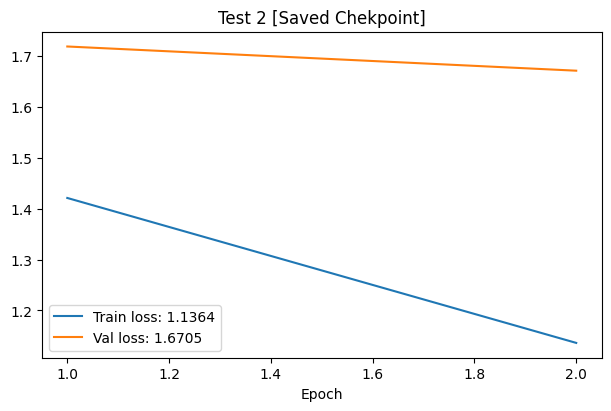

In [37]:
trainer_2.fit(model_2, train_data, val_data, 2, '../checkpoints/checkpoint2.pt')

In [20]:
snt_splt = Data.tokenize_snt("John likes reading books.", r"""['"€;:()$%–—‘’°“”₳+&#=‐…−/£@-]""", lambda x: x + ['<eos>'])[:34]
snt_splt

['john', 'likes', 'reading', 'books', '.', '<eos>']

In [25]:
ids_snt = [eng_vocab.get(tok, eng_vocab['<unk>']) for tok in snt_splt]
ids_snt

[429, 194, 383, 363, 3, 2]

In [20]:
import torch

In [28]:
torch.tensor(ids_snt).reshape(1, -1), torch.tensor([len(ids_snt)])

(tensor([[429, 194, 383, 363,   3,   2]]), tensor([6]))

In [67]:
torch.tensor([len(ids_snt)]).reshape(-1, 1)

tensor([[6]])

In [68]:
test_int = torch.repeat_interleave(torch.tensor([len(ids_snt)]).reshape(-1, 1), repeats=4, dim=0)
test_int

tensor([[6],
        [6],
        [6],
        [6]])

In [34]:
torch.arange((6), dtype=torch.float32)[None, :] > test_int

RuntimeError: The size of tensor a (6) must match the size of tensor b (4) at non-singleton dimension 1

In [21]:
from torch import nn

In [37]:
class PositionalEncoding2(nn.Module):
    def __init__(self, num_hiddens, dropout, seq_length=34):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, seq_length, num_hiddens))
        X = torch.arange(seq_length, dtype=torch.float32).reshape(-1, 1) / torch.pow(
            10000, torch.arange(0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)  # trzeba zmienic ostatni pewnie na :X.shape[2]
        return self.dropout(X)

In [38]:
posencod = PositionalEncoding2(num_hiddens, dropout)

In [47]:
embed = nn.Embedding(len(eng_vocab), num_hiddens)
test_X = torch.tensor([[429, 194, 383, 363,   3,   2]])
test_lin = nn.LazyLinear(num_hiddens, bias=False)

In [48]:
posencod(embed(test_X)).shape

torch.Size([1, 6, 256])

In [51]:
def transpose_qkv2(X):
    X = X.reshape(X.shape[0], X.shape[1], 4, -1).permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])

In [54]:
test_trans = transpose_qkv2(test_lin(posencod(embed(test_X))))
test_trans.shape

torch.Size([4, 6, 64])

In [56]:
import math

In [61]:
def sequence_mask2(X, valid_len, value=-1e6):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32)[None, :] < valid_len
        X[~mask] = value
        return X

In [62]:
test_score = (torch.bmm(test_trans, test_trans.mT) / math.sqrt(64))
test_score.shape

torch.Size([4, 6, 6])

In [65]:
test_int.reshape(-1, 1)

tensor([[6],
        [6],
        [6],
        [6]])